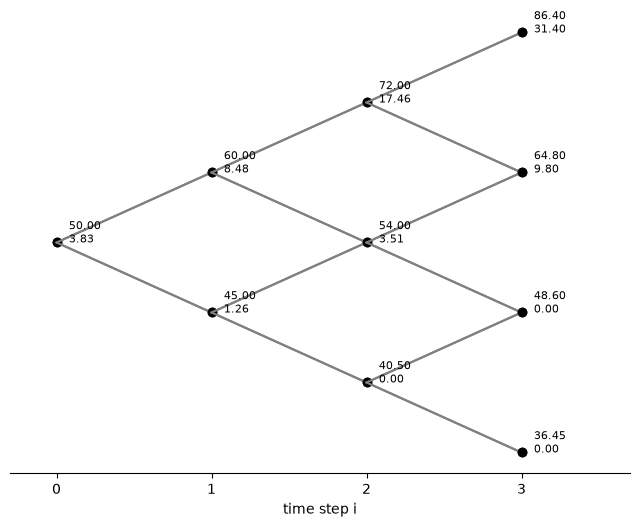

In [1]:
import matplotlib.pyplot as plt
import sys
import math
sys.path.append("..")
from src.lattice import stock_lattice, Euro_option_A, Euro_option_B, American_option_A, portfolio_tree
from src.payoffs import call, put

S0, u, d, r, T, n, K = 50, 1.2, 0.9, 0.05, 0.5, 3, 55
S = stock_lattice(S0, u, d, n)
V = Euro_option_A(S0, u, d, r, T, n, call(K))

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(n + 1):
    for j in range(i + 1):
        y = i - 2 * j
        ax.plot(i, y, 'o', color='black')
        if i < n:
            ax.plot([i, i + 1], [y, y + 1], '-', color='gray')   # 上行
            ax.plot([i, i + 1], [y, y - 1], '-', color='gray')   # 下行

for i in range(n + 1):
    for j in range(i + 1):
        y = i - 2 * j
        ax.plot(i, y, 'o', color='black')
        ax.text(i + 0.08, y, f"{S[i][j]:.2f}\n{V[i][j]:.2f}", fontsize=8)
        if i < n:
            ax.plot([i, i + 1], [y, y + 1], '-', color='gray')
            ax.plot([i, i + 1], [y, y - 1], '-', color='gray')

ax.set_xlim(-0.3, n + 0.7)
ax.set_xticks(range(n + 1))
ax.set_yticks([])
ax.set_xlabel("time step i")
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
plt.savefig("../figures/lattice_example.png", dpi=150, bbox_inches="tight")

plt.show()

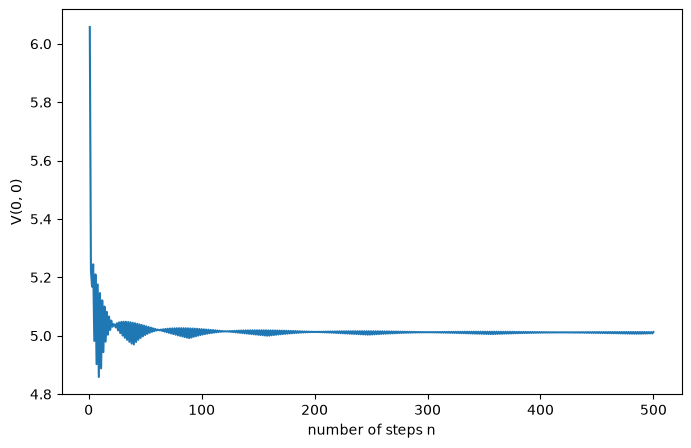

In [17]:
S0, r, T, K, sigma = 50, 0.05, 1, 55, 0.3
n_list = [n for n in range(1, 501)]
price_list = [0] * 500
fig, ax = plt.subplots(figsize=(8, 5))

for n in range(1, 501):
    delta_t = T / n
    u = math.exp(sigma * math.sqrt(delta_t))
    d = 1 / u
    option = Euro_option_B(S0, u, d, r, T, n, call(K))
    price_list[n - 1] = option
    
ax.set_xlabel("number of steps n")
ax.set_ylabel("V(0, 0)")
ax.plot(n_list, price_list)
plt.savefig("../figures/price_vs_n.png", dpi=150, bbox_inches="tight")
plt.show()

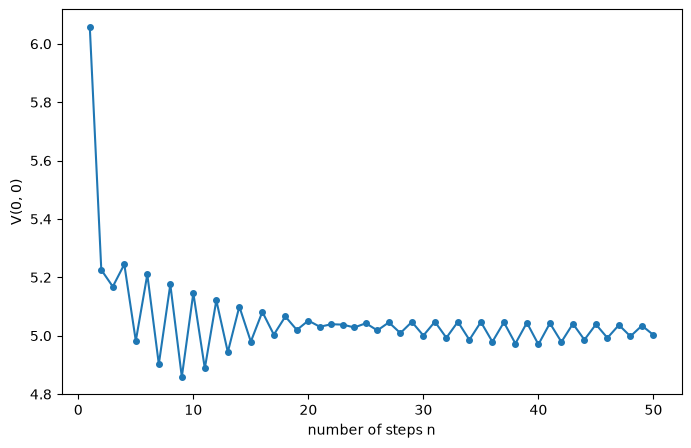

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(n_list[:50], price_list[:50], 'o-', markersize=4)

ax.set_xlabel("number of steps n")
ax.set_ylabel("V(0, 0)")

plt.savefig("../figures/price_vs_n_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

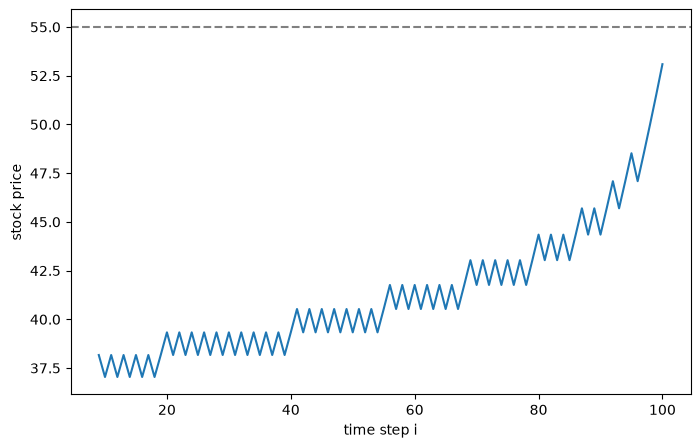

In [33]:
S0, r, T, K, sigma, n = 50, 0.05, 1, 55, 0.3, 100
delta_t = T / n
u = math.exp(sigma * math.sqrt(delta_t))
d = 1 / u

stock_price = stock_lattice(S0, u, d, n)
option_price, exercise = American_option_A(S0, u, d, r, T, n, put(K))

steps = []
boundary = []
for i in range(n + 1):
    highest = -1
    for j in range(i + 1):
        if exercise[i][j] and stock_price[i][j] > highest:
            highest = stock_price[i][j]
    if highest > 0:
        steps.append(i)
        boundary.append(highest)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(steps, boundary)
ax.axhline(K, linestyle="--", color="gray")
ax.set_xlabel("time step i")
ax.set_ylabel("stock price")
plt.savefig("../figures/exercise_boundary.png", dpi=150, bbox_inches="tight")
plt.show()

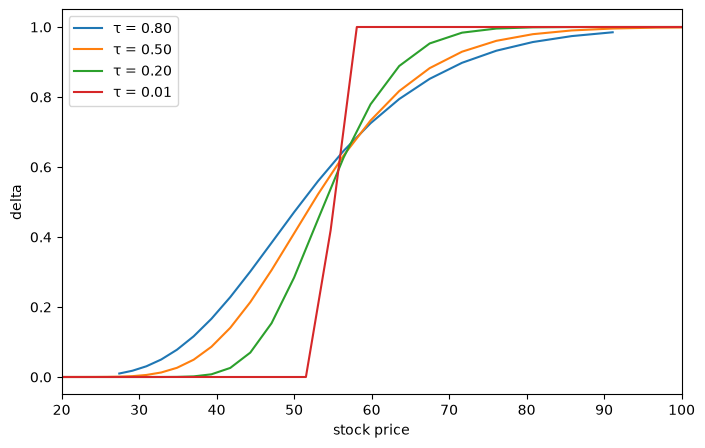

In [9]:
S0, r, T, K, sigma, n = 50, 0.05, 1, 55, 0.3, 100
delta_t = T / n
u = math.exp(sigma * math.sqrt(delta_t))
d = 1 / u

stock_price = stock_lattice(S0, u, d, n)
stock_share_tree, _ = portfolio_tree(S0, u, d, r, T, n, call(K))
time = [20, 50, 80, 99]

fig, ax = plt.subplots(figsize=(8, 5))
for i in time:
    stock_share = stock_share_tree[i][:i + 1]
    tstock_price = stock_price[i][:i + 1]
    ax.plot(tstock_price, stock_share, label=f"τ = {(n - i) * delta_t:.2f}")
    


ax.set_xlim(20, 100)
ax.legend()
ax.set_xlabel("stock price")
ax.set_ylabel("delta")

plt.savefig("../figures/delta_profile.png", dpi=150, bbox_inches="tight")
plt.show()